# DMD with Hankel preprocessing

In this demo notebook we show how you can apply Dynamic Mode Decomposition using Hankel preprocessing, also known as time-delay preprocessing. As discussed in [1], time-delay coordinates are a useful tool that can help unveil hidden or latent variables from our data. We can never be certain that our data matrix possesses high enough rank. It may lack some crucial observables, and time-delay preprocessing may help in these scenarios.

Much of this notebook builds on [dmd_demo_1.ipynb](dmd_demo_1.ipynb), so you are encouraged to look at that one first before jumping into this one.

## How Hankel preprocessing works

<img src="media/hankel_preprocessing.png" width="50%" />

The figure above illustrates how Hankel/time-delay preprocessing works. Imagine you have *m* snapshots organized in time, where each snapshot has *n* samples (e.g. different spatial locations). Time-delay preprocessing involves converting the initial $(n, m)$ matrix into a $(d*n, m-d-1)$ matrix by augmenting each snapshot with copies of $(d-1)$ succeeding snapshots. In the figure above $d=2$, meaning we augment each snapshot by a single time delay.


## Challenges of Hankel preprocessing

The main challenge of applying time-delay preprocessing to a huge matrix is that the resulting matrix grows in size by a factor of $d$. Imagine the $(n, m)$ matrix of the figure above had size $(10^6, 1000)$. After performing time-delay preprocessing, it would have size $(2 \times 10^6, 999)$.


## References

[1] *PyDMD: A Python package for robust dynamic mode decomposition, Ichinaga et al. (2024)*


In [1]:
from __future__ import annotations

import pickle

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from dask.distributed import Client
from utils import compute_climatology, compute_rmse

from svdrom.dmd import OptDMD
from svdrom.preprocessing import (
    StandardScaler,
    hankel_preprocessing,
    variable_spatial_stack,
)
from svdrom.svd import TruncatedSVD

## 1. Perform Hankel preprocessing

Before computing the SVD or the DMD, we need to preprocess our data matrix $\mathbf{X}$. For this we can use the `hankel_preprocessing()` function from the `svdrom.preprocessing` module. As with most of the SVD-ROM package, `hankel_preprocessing()` uses Dask to perform Hankel preprocessing in parallel and out-of-core, so the first think we need to do is to start a multi-threaded Dask cluster.

In [2]:
client = Client(processes=False)  # start a local multi-threaded Dask cluster

In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://192.168.0.175:8787/status,
Dashboard: http://192.168.0.175:8787/status,Workers: 1
Total threads: 10,Total memory: 32.00 GiB
Status: running,Using processes: False
Comm: inproc://192.168.0.175/4863/1,Workers: 0
Dashboard: http://192.168.0.175:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: inproc://192.168.0.175/4863/4,Total threads: 10
Dashboard: http://192.168.0.175:57547/status,Memory: 32.00 GiB
Nanny: None,


We will now open the slice of the ERA5 dataset that we have stored on disk, containing temperature data over a period of approximately 4 years at a pressure level of 500 hPa. The notebook [download_era5_slice.ipynb](download_era5_slice.ipynb) shows you how you can download it. We will slice the dataset between 2016-01-01 and 2019-12-31, as we did in [dmd_demo_1.ipynb](dmd_demo_1.ipynb), which gives an array of approximately 34 GiB.

In [ ]:
era5_path = "data/era5_slice.zarr"
X = xr.open_dataarray(era5_path, chunks="auto")

In [4]:
X = X.sel(time=slice("2016-01-01", "2019-12-31"))
X

<xarray.DataArray 'temperature' (time: 8766, latitude: 721, longitude: 1440)> Size: 36GB
dask.array<getitem, shape=(8766, 721, 1440), dtype=float32, chunksize=(32, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 70kB 2016-01-01 ... 2019-12-31T20:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    level      int64 8B ...
Attributes:
    long_name:      Temperature
    short_name:     t
    standard_name:  air_temperature
    units:          K

Now we will remove the time average and perform stacking of the `latitude` and `longitude` coordinates.

In [5]:
scaler = StandardScaler()
X = scaler(X)

2026-01-22 21:43 - Preprocessing - INFO - Computing mean along dimension time...
[preprocessing.py:133 -             __call__() ] Computing mean along dimension time...
2026-01-22 21:43 - Preprocessing - INFO - Finished computing mean.
[preprocessing.py:136 -             __call__() ] Finished computing mean.


In [6]:
X = variable_spatial_stack(X, dims=("latitude", "longitude"))

2026-01-22 21:44 - Preprocessing - INFO - Performing spatial stacking.
[preprocessing.py:64 - variable_spatial_stack() ] Performing spatial stacking.


Finally we transpose the matrix to obtain dimensions *(samples, time)*.

In [7]:
X = X.T  # transpose the matrix to obtain dimensions space (or samples) x time

In [8]:
X

<xarray.DataArray 'temperature' (samples: 1038240, time: 8766)> Size: 36GB
dask.array<transpose, shape=(1038240, 8766), dtype=float32, chunksize=(1038240, 32), chunktype=numpy.ndarray>
Coordinates:
  * samples    (samples) object 8MB MultiIndex
  * time       (time) datetime64[ns] 70kB 2016-01-01 ... 2019-12-31T20:00:00
    level      int64 8B 500
  * latitude   (samples) float32 4MB 90.0 90.0 90.0 90.0 ... -90.0 -90.0 -90.0
  * longitude  (samples) float32 4MB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

All the array transformations operations so far have been lazy (they have not yet been computed). All we have done is build the Dask task graph. We will now perform Hankel preprocessing, which is also a lazy operation. By default, `hankel_preprocessing()` will perform time-delay preprocessing with $d=2$. You can change this to a bigger number but remember the size of the matrix grows proportionally to $d$!

In [9]:
X_hankel = hankel_preprocessing(X)

As shown below, we have duplicated the number of rows in the matrix and reduced the number of columns by one. The resulting matrix is now almost 70 GiB in size.

In [11]:
print(f"Shape of X: {X.shape}")
print(f"Shape of X_hankel: {X_hankel.shape}")
print(f"Size of X: {X.nbytes / 1024 ** 3:.2f} GiB")
print(f"Size of X_hankel: {X_hankel.nbytes / 1024 ** 3:.2f} GiB")

Shape of X: (1038240, 8766)
Shape of X_hankel: (2076480, 8765)
Size of X: 33.90 GiB
Size of X_hankel: 67.80 GiB


## 2. Compute the SVD

Once we have done the preprocessing, we are ready to perform the SVD. As was discussed in [dmd_demo_1.ipynb](dmd_demo_1.ipynb), the first step of the DMD calculation is to do a SVD so that we get a low-order representation of the data on which we can then fit a DMD model. As before, we will perform a randomized SVD with power iterations and oversampling for better accuracy. 

In [ ]:
rand_svd_hankel = TruncatedSVD(
    n_components=40,
    algorithm="randomized",
    rechunk=True,
    compute_var_ratio=True,
)

So far all the operations have been lazy. When we fit the SVD below, we will trigger the Dask task graph.

WARNING: we are computing a SVD on a huge array (much larger than RAM) on a laptop. Despite this, Dask was able to do it in under 10 min (I am running this notebook on a Mac M1 Pro with 32 GB of RAM and 10 cores), as shown below. However, it is very likely that Dask will need to spill to disk quite a bit, so make sure you have enough disk space available so Dask can use it as secondary memory (at least a few 10s of GB).

In [ ]:
rand_svd_hankel.fit(X_hankel, n_power_iter=2, n_oversamples=15)

2026-01-21 16:45 - SVD - INFO - Will use randomized algorithm.
[svd.py:263 -                  fit() ] Will use randomized algorithm.
2026-01-21 16:45 - SVD - INFO - The input array is considered tall-and-skinny. Will rechunk the array before fitting the SVD. This will add some overhead.
[svd.py:143 -       _rechunk_array() ] The input array is considered tall-and-skinny. Will rechunk the array before fitting the SVD. This will add some overhead.
2026-01-21 16:45 - SVD - INFO - Computing SVD results...
[svd.py:284 -                  fit() ] Computing SVD results...
2026-01-21 16:52 - SVD - INFO - Done.
[svd.py:287 -                  fit() ] Done.


We are done with Dask for now so let's close the cluster.

In [ ]:
client.close()

Let's now save the fitted `TruncatedSVD` instance and the `StandardScaler` instance to disk.

In [ ]:
with open("data/results/hankel_dmd/rand_svd_results.pkl", "wb") as f:
    pickle.dump(rand_svd_hankel, f)

with open("data/results/hankel_dmd/standard_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

Let's now plot the explained variance by successive SVD components. We will compare this to the SVD model fitted on the original data without time-delay preprocessing which we computed in [dmd_demo_1.ipynb](dmd_demo_1.ipynb).

In [5]:
with open("data/results/rand_svd_results.pkl", "rb") as f:
    rand_svd = pickle.load(f)

In [6]:
with open("data/results/hankel_dmd/rand_svd_results.pkl", "rb") as f:
    rand_svd_hankel = pickle.load(f)

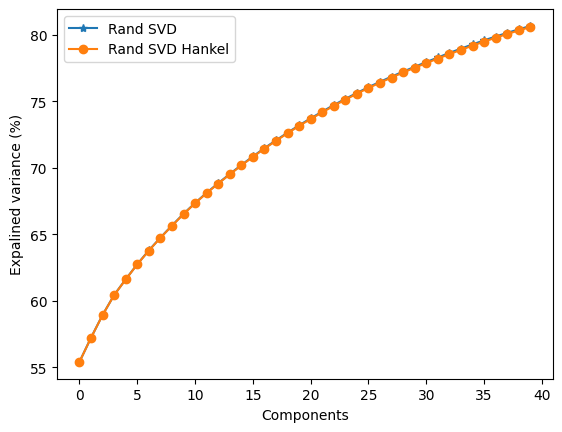

In [ ]:
plt.plot(np.cumsum(rand_svd.explained_var_ratio)*100, "*-", label="Rand SVD")
plt.plot(
    np.cumsum(rand_svd_hankel.explained_var_ratio)*100, "o-", label="Rand SVD Hankel"
)
plt.xlabel("Components")
plt.ylabel("Expalined variance (%)")
plt.legend()
plt.show()

As shown the eigenvalue distribution looks very similar, which is to be expected because we have only included one time lag and the time difference between snapshots is quite small (4 hours), so we are not augmenting the matrix with too much signal history.

## 3. Compute the DMD

Load the fitted `TruncatedSVD` instance we computed earlier if it's not already loaded.

In [2]:
with open("data/results/hankel_dmd/rand_svd_results.pkl", "rb") as f:
    rand_svd_hankel = pickle.load(f)

In [dmd_demo_1.ipynb](dmd_demo_1.ipynb) we saw that an optimized DMD model with 30 modes provided good results, so we will now try the same with the Hankel preprocessed data.

In [5]:
# 30 modes, without bagging
optdmd_30_hankel = OptDMD(
    n_modes=30,
    time_units="h",
)

As shown below, after computing the SVD on the Hankel preprocessed matrix, we can compute the DMD in less than a minute using the SVD results.

In [6]:
%%time
# no bagging, runs sequentially
optdmd_30_hankel.fit(
    rand_svd_hankel.u,
    rand_svd_hankel.s,
    rand_svd_hankel.v,
)

2026-01-22 20:39 - DMD - INFO - Computing the DMD fit...
[dmd.py:624 -                  fit() ] Computing the DMD fit...


/Users/dsalvadorjasin/Documents/projects/svdrom/.venv/lib/python3.12/site-packages/pydmd/bopdmd.py:998: UserWarning: Initial trial of Optimized DMD failed to converge. Consider re-adjusting your variable projection parameters with the varpro_opts_dict and consider setting verbose=True.
  warnings.warn(msg)
2026-01-22 20:40 - DMD - INFO - Done.
[dmd.py:640 -                  fit() ] Done.


CPU times: user 38.5 s, sys: 12 s, total: 50.5 s
Wall time: 40.3 s


Save the DMD results to disk.

In [7]:
with open("data/results/hankel_dmd/optdmd_30_modes.pkl", "wb") as f:
    pickle.dump(optdmd_30_hankel, f)

Because time-delay preprocessing has duplicated the number of samples (rows) in the matrix, the DMD modes are also twice as big. You can call the `modes_averaged` property to average the modes across lags to enable visualization in the original lat-lon space.

In [8]:
print(optdmd_30_hankel.modes.shape)
print(optdmd_30_hankel.modes_averaged.shape)

(2076480, 30)
(1038240, 30)


We will sort the modes by decreasing amplitude.

In [11]:
mode_order = np.argsort(-np.abs(optdmd_30_hankel.amplitudes))
print(mode_order)

[29 28 26 27 25 24 19 18 14 15  5  4 17 16 23 22 10 11 21 20  7  6  9  8
 12 13  2  3  0  1]


In [12]:
modes = optdmd_30_hankel.modes_averaged.unstack()  # unstack to return to lat-lon coords

In [13]:
modes

<xarray.DataArray 'dmd_modes' (components: 30, latitude: 721, longitude: 1440)> Size: 498MB
array([[[ 0.00039077-4.38247812e-05j,  0.00039077-4.38247812e-05j,
          0.00039077-4.38247812e-05j, ...,  0.00039085-4.39444495e-05j,
          0.00039085-4.39444495e-05j,  0.00039085-4.39444495e-05j],
        [ 0.00036313-4.22581025e-05j,  0.00039043-5.11734139e-05j,
          0.00037231-3.31777286e-05j, ...,  0.00038628-3.79320986e-05j,
          0.00039164-3.77532680e-05j,  0.00037965-3.07870479e-05j],
        [ 0.00037075-3.23494490e-05j,  0.00040266-3.20716587e-05j,
          0.00040094-1.44683004e-05j, ...,  0.00039775-3.41669529e-05j,
          0.00038093-1.76628631e-05j,  0.00037538-3.29066425e-05j],
        ...,
        [-0.00075097+1.27610238e-04j, -0.0007348 +1.50330654e-04j,
         -0.00074612+1.71744887e-04j, ..., -0.00071165+1.36724203e-04j,
         -0.00078523+9.68329995e-05j, -0.00076583+9.71468409e-05j],
        [-0.00076321+1.08790765e-04j, -0.00076193+1.26013988e-04j,
         -0.00077492+1.25881133e-04j, ..., -0.00076793+1.51512463e-04j,
         -0.00078072+1.38262341e-04j, -0.00077737+1.36048189e-04j],
        [-0.00075419+1.72304041e-04j, -0.00075419+1.72304025e-04j,
         -0.00075419+1.72304023e-04j, ..., -0.00075419+1.72304025e-04j,
         -0.00075419+1.72304025e-04j, -0.00075419+1.72304025e-04j]],

...
       [[ 0.00053189+1.45785066e-04j,  0.00053189+1.45785066e-04j,
          0.00053189+1.45785066e-04j, ...,  0.00053189+1.45777755e-04j,
          0.00053189+1.45777755e-04j,  0.00053189+1.45777755e-04j],
        [ 0.0005328 +1.44725816e-04j,  0.00053305+1.44941358e-04j,
          0.00053323+1.44414130e-04j, ...,  0.00053316+1.44378011e-04j,
          0.00053301+1.44510168e-04j,  0.00053317+1.44137986e-04j],
        [ 0.00053467+1.43716845e-04j,  0.00053436+1.44288669e-04j,
          0.00053501+1.43499817e-04j, ...,  0.00053459+1.43779626e-04j,
          0.0005339 +1.44691513e-04j,  0.00053395+1.45119135e-04j],
        ...,
        [-0.00094376-4.50810649e-04j, -0.00094483-4.50278465e-04j,
         -0.0009433 -4.51771356e-04j, ..., -0.00094365-4.49498410e-04j,
         -0.00094593-4.46842808e-04j, -0.00094606-4.46540132e-04j],
        [-0.00094805-4.42632125e-04j, -0.00094854-4.42376975e-04j,
         -0.00094818-4.42331311e-04j, ..., -0.00094801-4.42444377e-04j,
         -0.00094883-4.41291083e-04j, -0.00094877-4.40883975e-04j],
        [-0.00094962-4.38452168e-04j, -0.00094962-4.38452173e-04j,
         -0.00094962-4.38452173e-04j, ..., -0.00094962-4.38452173e-04j,
         -0.00094962-4.38452173e-04j, -0.00094962-4.38452173e-04j]]],
      shape=(30, 721, 1440))
Coordinates:
  * components  (components) int64 240B 0 1 2 3 4 5 6 7 ... 23 24 25 26 27 28 29
  * latitude    (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8

We will now plot the first DMD mode (the one with largest amplitude). As shown in the plot, it clearly represents the summer/winter fluctuation, with a clear separation between the Northern and Southern hemispheres. This is identical to what we got in [dmd_demo_1.ipynb](dmd_demo_1.ipynb).

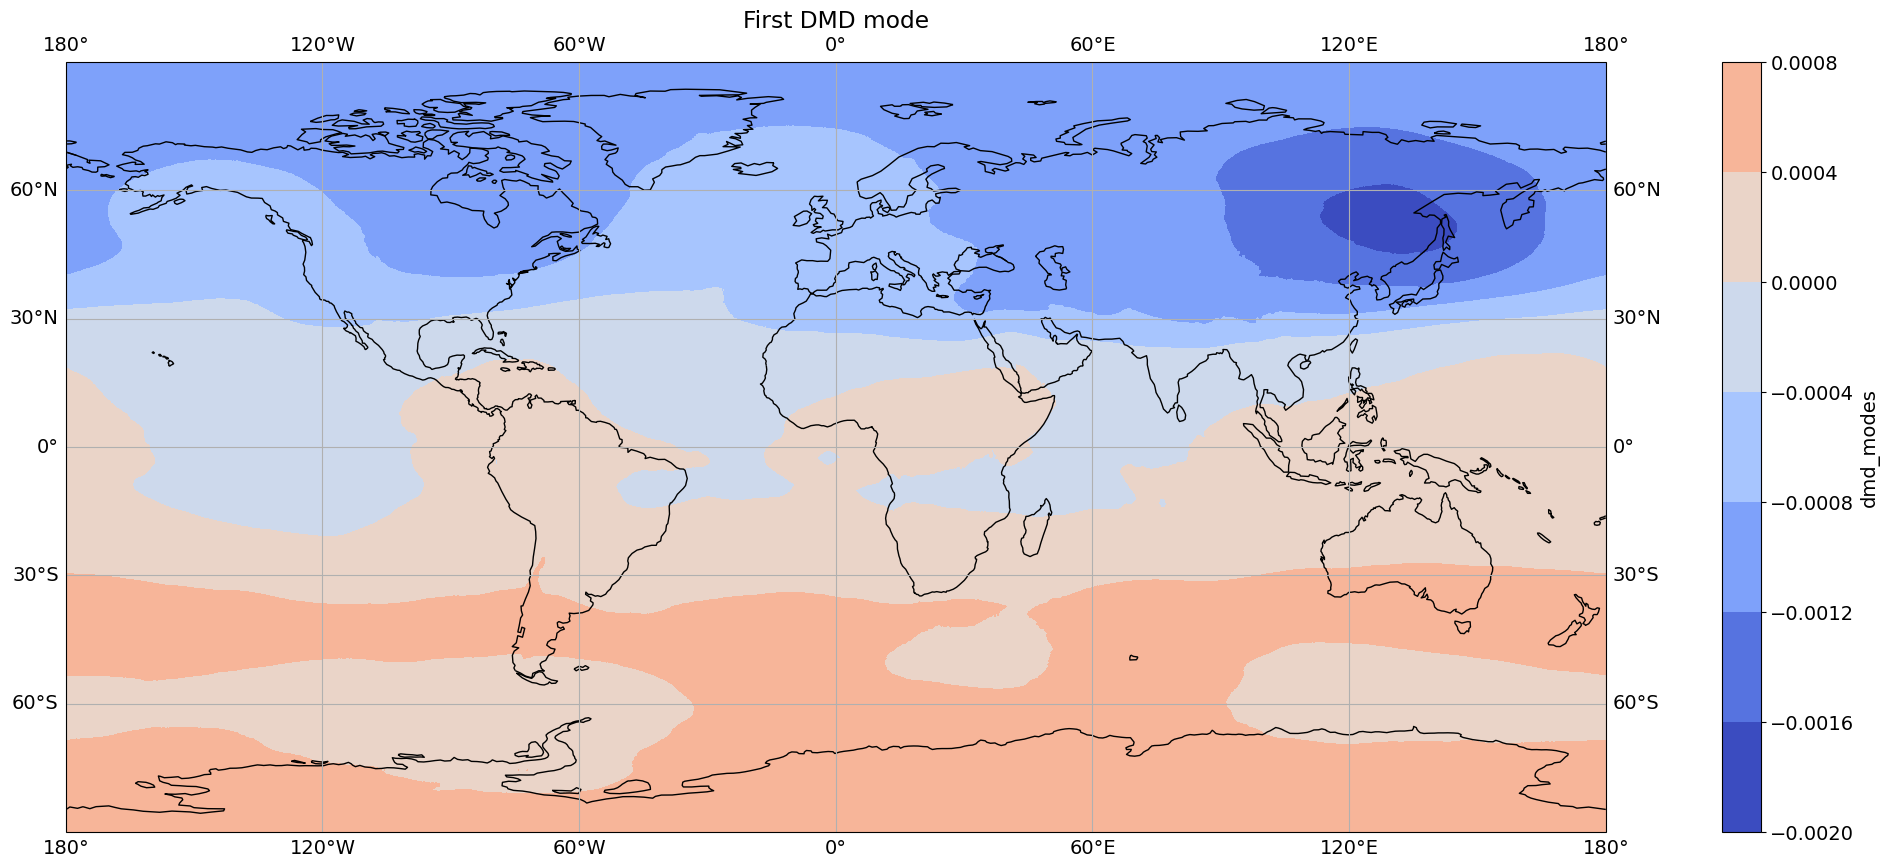

In [14]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(30, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# plot the real part of the DMD mode with highest amplitude
modes[mode_order[0], :, :].real.plot.contourf(
    ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
)
ax.coastlines(color='black')
ax.gridlines(draw_labels=True)

plt.title("First DMD mode")
plt.show()

The dynamics of the first mode very clearly show the annual periodicity.

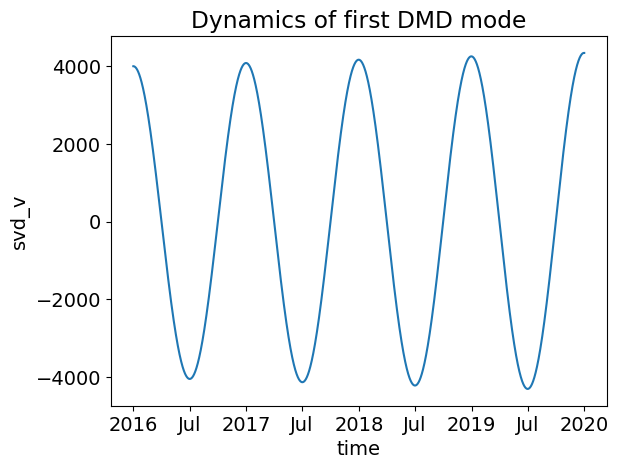

In [15]:
# plot the real part of the temporal evolution of the first DMD mode
optdmd_30_hankel.dynamics[mode_order[0], :].real.plot()
plt.title("Dynamics of first DMD mode")
plt.show()

## 4. Evaluate the DMD model

We will evaluate the DMD model we computed above, and compare it to the DMD model without Hankel preprocessing of [dmd_demo_1.ipynb](dmd_demo_1.ipynb). We will perform reconstructions and forecasts, so now we will need Dask again. Start a local multi-threaded Dask cluster.

In [17]:
client = Client(processes=False)

2026-01-22 20:57 - Dask Setup - INFO - Started a local multi-thread Dask cluster with dashboard support.
2026-01-22 20:57 - Dask Setup - INFO - Dashboard link: http://localhost:8787/status


We will need the fitted DMD instance as well as the `StandardScaler` instance, as this contains the computed time-average.

In [22]:
with open("data/results/hankel_dmd/optdmd_30_modes.pkl", "rb") as f:
    optdmd_30_hankel = pickle.load(f)

In [23]:
with open("data/results/hankel_dmd/standard_scaler.pkl", "rb") as f:
    scaler_hankel = pickle.load(f)

Reconstruct the training data between 1st Nov 2019 and 31st Dec 2019, inclusive

In [34]:
recon_hankel = optdmd_30_hankel.reconstruct(
    t=slice("2019-11-01T00", "2019-12-31T20")
)  # this is lazy

2026-01-22 21:10 - DMD - INFO - Estimated reconstruction size is 12159866.880 KB.
[dmd.py:1260 -          reconstruct() ] Estimated reconstruction size is 12159866.880 KB.
2026-01-22 21:10 - DMD - INFO - Will use Dask to compute the reconstruction.
[dmd.py:1264 -          reconstruct() ] Will use Dask to compute the reconstruction.
2026-01-22 21:10 - DMD - INFO - Computing the DMD reconstruction...
[dmd.py:1270 -          reconstruct() ] Computing the DMD reconstruction...
2026-01-22 21:10 - DMD - INFO - Done.
[dmd.py:1277 -          reconstruct() ] Done.


In [35]:
recon_hankel = recon_hankel.unstack()

Here we add the time average we removed at the start back to the DMD reconstruction.

In [36]:
recon_hankel = recon_hankel.copy(data=recon_hankel+scaler_hankel.mean)

This will trigger the Dask computations and save to disk as a Zarr store chunk by chunk as they become available.

In [37]:
recon_hankel.to_zarr(
    "data/results/hankel_dmd/recon_optdmd_30_modes_NovDec2019.zarr",
    zarr_format=2,
    mode="w",
)

/Users/dsalvadorjasin/Documents/projects/svdrom/.venv/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 0.97 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


We will now compute a 45 day forecast.

In [38]:
forecast_hankel = optdmd_30_hankel.forecast(
    forecast_span="45 D", dt=None
)  # this is lazy

2026-01-22 21:10 - DMD - INFO - Estimated forecast size is 8970393.600 KB.
[dmd.py:1049 -             forecast() ] Estimated forecast size is 8970393.600 KB.
2026-01-22 21:10 - DMD - INFO - Will use Dask to compute the forecast.
[dmd.py:1052 -             forecast() ] Will use Dask to compute the forecast.
2026-01-22 21:10 - DMD - INFO - Computing the DMD forecast...
[dmd.py:1058 -             forecast() ] Computing the DMD forecast...
2026-01-22 21:10 - DMD - INFO - Done.
[dmd.py:1065 -             forecast() ] Done.


Unstack to recover the original lat-lon coordinates and add back the mean.

In [39]:
forecast_hankel = forecast_hankel.unstack()

In [40]:
forecast_hankel = forecast_hankel.copy(data=forecast_hankel+scaler_hankel.mean)

This will trigger the Dask computations and save to disk as a Zarr store chunk by chunk as they become available.

In [41]:
forecast_hankel.to_zarr(
    "data/results/hankel_dmd/forecast_optdmd_30_modes_45_days.zarr",
    zarr_format=2,
    mode="w",
)

/Users/dsalvadorjasin/Documents/projects/svdrom/.venv/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 0.97 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Now that we have computed and saved the reconstruction and forecast to disk, we can compare them to the results of the DMD model without Hankel preprocessing, as well as to climatology.

In [46]:
ground_truth = xr.open_dataarray("data/era5_slice.zarr", chunks={"time": 16})

recon = xr.open_dataarray(
    "data/results/recon_optdmd_30_modes_NovDec2019.zarr", chunks={"time": 16}
)  # without Hankel preprocessing

forecast = xr.open_dataarray(
    "data/results/forecast_optdmd_30_modes_45_days.zarr", chunks={"time": 16}
)  # without Hankel preprocessing

recon_hankel = xr.open_dataarray(
    "data/results/hankel_dmd/recon_optdmd_30_modes_NovDec2019.zarr", chunks={"time": 16}
)  # with Hankel preprocessing

forecast_hankel = xr.open_dataarray(
    "data/results/hankel_dmd/forecast_optdmd_30_modes_45_days.zarr", chunks={"time": 16}
)  # with Hankel preprocessing


Compute a climatological forecast for Jan and Feb 2020. This will use the Dask cluster that we have got running.

In [45]:
climatology = compute_climatology(
    ground_truth.sel(time=slice("2016-01-01", "2019-12-31")),
    year=2020,
    months=[1, 2],
)

Now compute the RMSE for the reconstruction and forecasts. Will also use the Dask cluster.

In [47]:
rmse_recon_hankel = compute_rmse(
    ground_truth.sel(time=slice("2019-11", "2019-12")),
    recon_hankel,
)

In [48]:
rmse_recon = compute_rmse(
    ground_truth.sel(time=slice("2019-11", "2019-12")),
    recon,
)

In [49]:
rmse_forecast_hankel = compute_rmse(
    ground_truth.sel(time=forecast_hankel.time),
    forecast_hankel,
)

In [50]:
rmse_forecast = compute_rmse(
    ground_truth.sel(time=forecast.time),
    forecast,
)

In [51]:
rmse_climatology = compute_rmse(
    ground_truth.sel(time=forecast_hankel.time),
    climatology.sel(time=forecast_hankel.time),
)

/Users/dsalvadorjasin/Documents/projects/svdrom/.venv/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 1.04 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Below we plot the RMSE for the reconstructions and forecasts. To the left of the vertical line (i.e. before 1 Jan 2020), we have the reconstruction RMSE. To the right, we have the forecast RMSE. Clearly both optimized DMD models beat the climatological forecast, but Hankel preprocessing with one time-delay  has not provided any visible improvements in the accuracy of the solution in this case. As discussed above, a possible reason is that we are not adding much additional history to augment the snapshots with hidden/latent information.

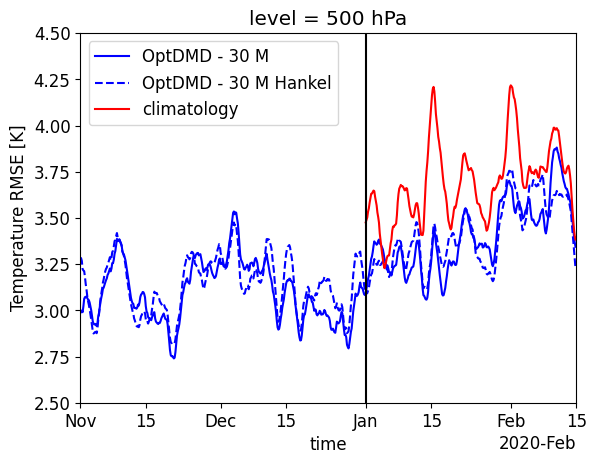

In [53]:
plt.rcParams.update({'font.size': 12})
rmse = xr.concat([rmse_recon, rmse_forecast], dim="time")
rmse_hankel = xr.concat([rmse_recon_hankel, rmse_forecast_hankel], dim="time")
rmse.plot(label="OptDMD - 30 M", color="blue", linestyle="-")
rmse_hankel.plot(label="OptDMD - 30 M Hankel", color="blue", linestyle="--")
rmse_climatology.plot(label="climatology", color="red")
plt.xlim([np.datetime64("2019-11-01T00:00"), np.datetime64("2020-02-15T00:00")])
plt.ylim([2.5, 4.5])
plt.ylabel("Temperature RMSE [K]")
plt.axvline(x=np.datetime64("2020-01-01T00:00"), color="black")
plt.legend()
plt.title("level = 500 hPa")
plt.show()

It's good practice to close the Dask cluster.

In [54]:
client.close()

## Conclusion

This notebook has shown that SVD-ROM allows you to easily perform Hankel pre-processing prior to DMD, and to do so at scale on huge arrays. In this particular case Hankel preprocessing has not helped much, but it would be worth investigating whether a different ERA5 slice (e.g. a longer time period with a larger time delta between snapshots e.g. 12 hours instead of 4) would benefit from the same type of preprocessing. Alternatively, one could try adding more time delays in the Hankel preprocessing, but the matrix would become truly enormous and might difficult to handle on a laptop. In this example, the Hankel preprocessed matrix had approximately 70 GiB. If we added one more time delay, it would be over 100 GiB.